In [1]:
import sys
sys.path.append('../../../../src')
import pickle
from energiapy.plot import plot_results, plot_scenario, plot_location
from matplotlib import pyplot as plt
from matplotlib import rc
import numpy as np

In [2]:
dark_colors = [
    "black",
    "dimgray",
    "gray",
    "dimgrey",
    "slategrey",
    "darkslategray",
    "darkslategrey",
    "darkgray",
    "darkblue",
    "midnightblue",
    "navy",
    "darkgreen",
    "forestgreen",
    "darkolivegreen",
    "darkred",
    "firebrick",
    "maroon",
    "darkmagenta",
    "indigo",
    "darkviolet",
    "purple",
    "darkorange",
    "saddlebrown",
    "chocolate",
    "darkgoldenrod"
]

In [3]:
with open(f'control/ncl_ControlResults_Backlog.pkl', 'rb') as file:
    ncl_load_results = pickle.load(file)

In [4]:
with open(f'control/cl_ControlResults_Backlog.pkl', 'rb') as file:
    cl_load_results = pickle.load(file)

In [5]:
with open(f'control/cl_step2_ControlResults_Backlog.pkl', 'rb') as file:
    cl_step2_load_results = pickle.load(file)

In [6]:
with open(f'control/cl_step2_ControlResults_Backlog_ncl_des.pkl', 'rb') as file:
    cl_step2_ncl_des_load_results = pickle.load(file)

In [7]:
with open(f'control/cl_step3_ControlResults_Backlog.pkl', 'rb') as file:
    cl_step3_load_results = pickle.load(file)

In [8]:
# with open(f'control/ncl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
#     ph30_ncl_load_results = pickle.load(file)

In [9]:
# with open(f'control/cl_ControlResults_Backlog_ph30.pkl', 'rb') as file:
#     ph30_cl_load_results = pickle.load(file)

In [21]:
print(*[(k,v) for k,v in cl_step3_load_results.output['P'].items() if k[0]=='loc2' and k[1]=='com1_process' and v], sep='\n')

(('loc2', 'com1_process', 0, 0, 3), 445.0)
(('loc2', 'com1_process', 0, 0, 4), 445.0)
(('loc2', 'com1_process', 0, 0, 5), 100.0)
(('loc2', 'com1_process', 0, 0, 6), 100.0)
(('loc2', 'com1_process', 0, 1, 0), 100.0)
(('loc2', 'com1_process', 0, 1, 1), 100.0)
(('loc2', 'com1_process', 0, 1, 2), 100.0)
(('loc2', 'com1_process', 0, 1, 3), 100.0)
(('loc2', 'com1_process', 0, 1, 4), 100.0)
(('loc2', 'com1_process', 0, 1, 5), 100.0)
(('loc2', 'com1_process', 0, 1, 6), 100.0)
(('loc2', 'com1_process', 0, 2, 0), 100.0)
(('loc2', 'com1_process', 0, 2, 1), 100.0)
(('loc2', 'com1_process', 0, 2, 2), 100.0)
(('loc2', 'com1_process', 0, 2, 3), 100.0)
(('loc2', 'com1_process', 0, 2, 4), 100.0)
(('loc2', 'com1_process', 0, 2, 5), 100.0)
(('loc2', 'com1_process', 0, 2, 6), 100.0)
(('loc2', 'com1_process', 0, 3, 0), 100.0)
(('loc2', 'com1_process', 0, 3, 1), 100.0)
(('loc2', 'com1_process', 0, 3, 2), 100.0)
(('loc2', 'com1_process', 0, 3, 3), 100.0)
(('loc2', 'com1_process', 0, 3, 4), 100.0)
(('loc2', '

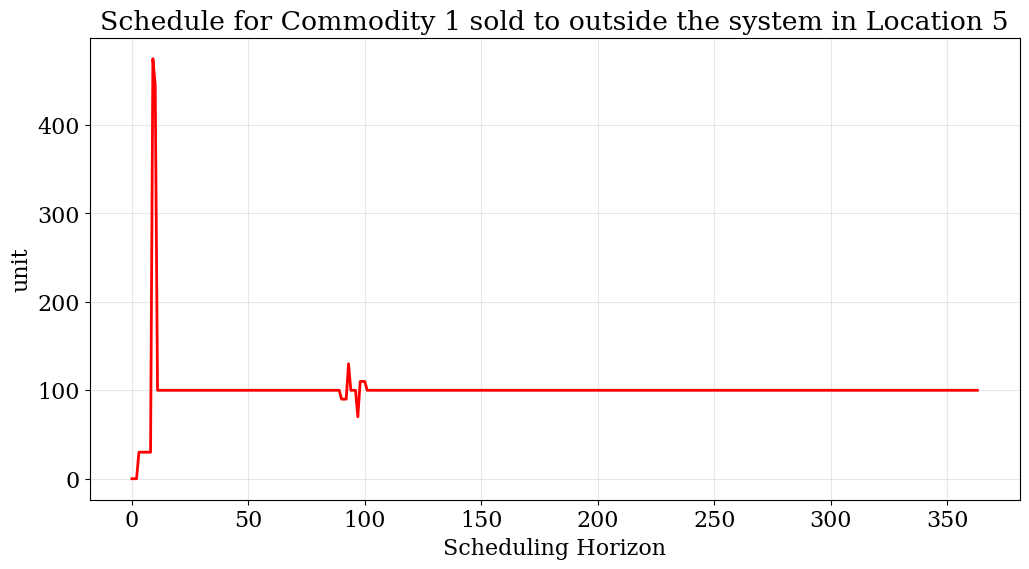

In [10]:
plot_results.schedule(results=ncl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

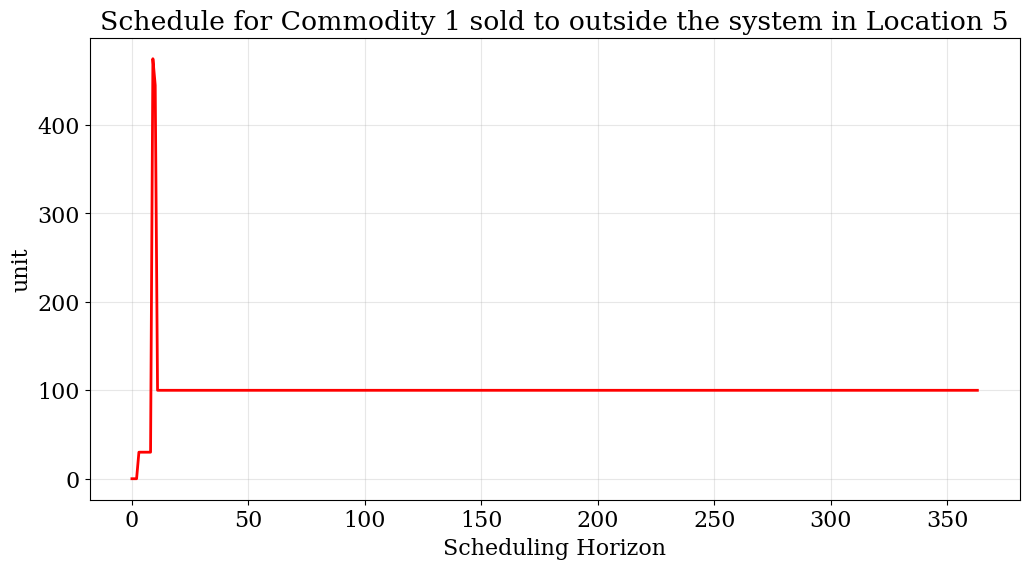

In [11]:
plot_results.schedule(results=cl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

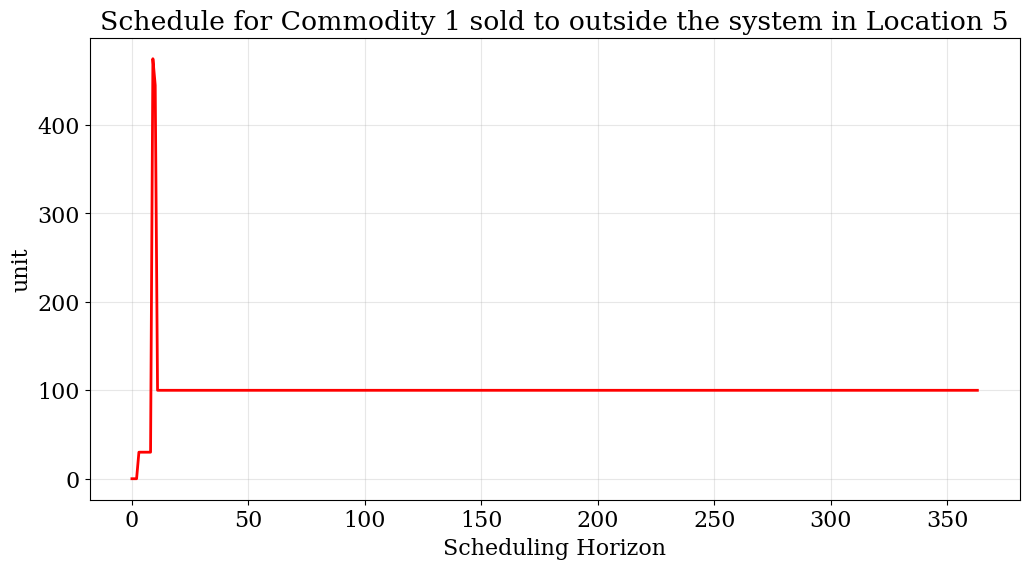

In [12]:
plot_results.schedule(results=cl_step2_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

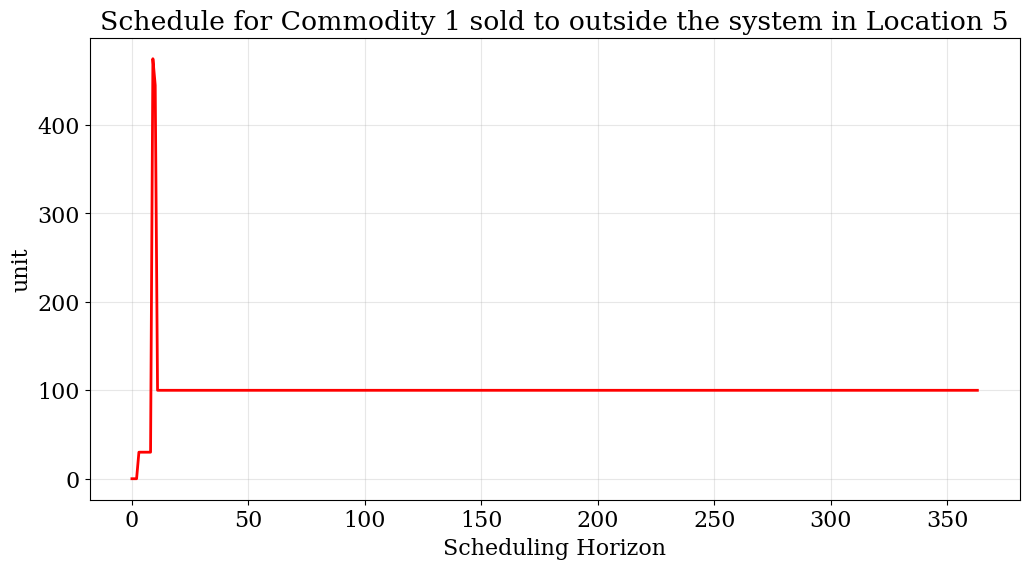

In [13]:
plot_results.schedule(results=cl_step2_ncl_des_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

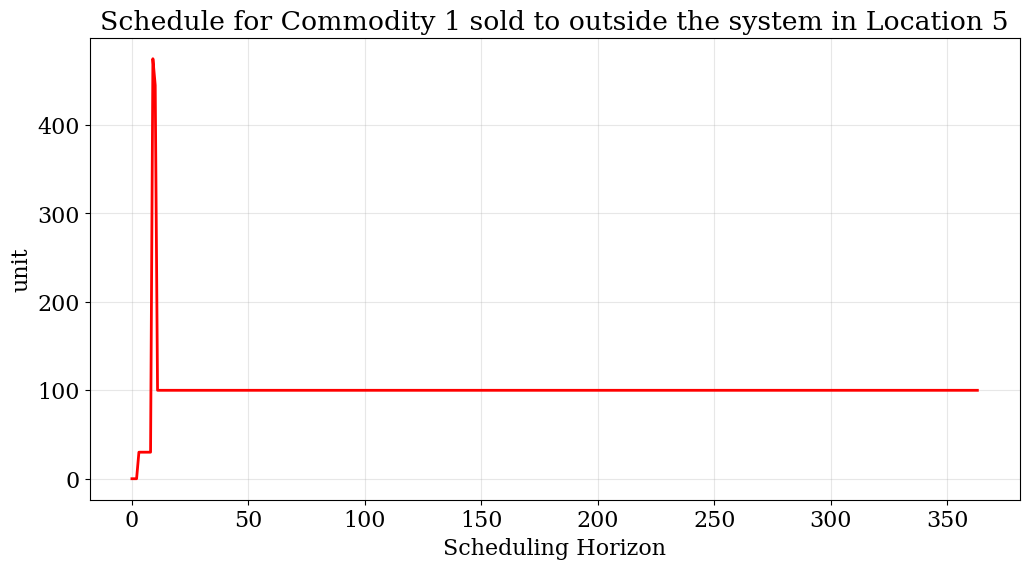

In [14]:
plot_results.schedule(results=cl_step3_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

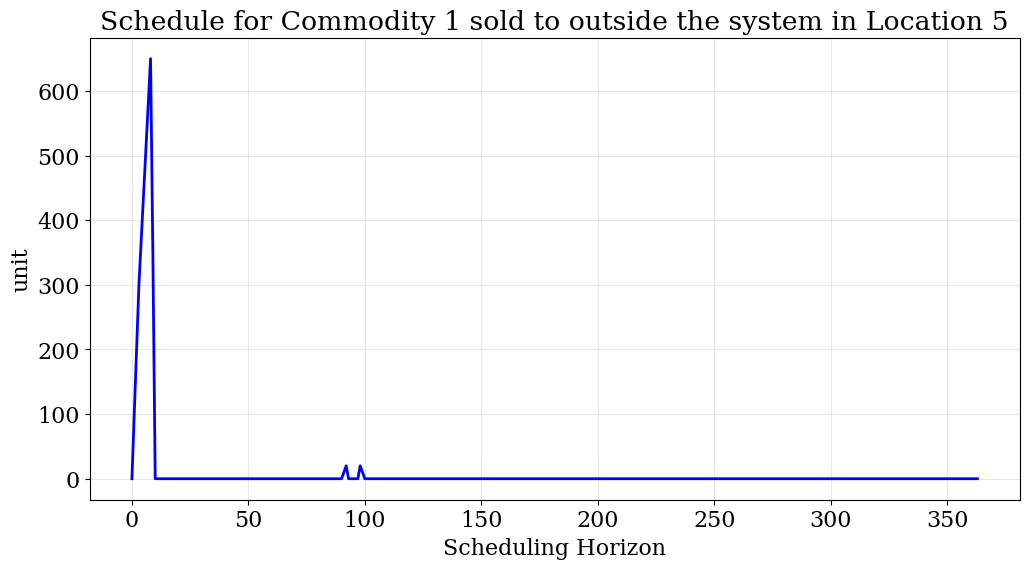

In [14]:
plot_results.schedule(results=ncl_load_results, y_axis='Demand_backlog', component='com1_sold', location='loc5')

In [15]:
# a = ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
a = ncl_load_results.output['objective']
# b = cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
b = cl_load_results.output['objective']
(b-a)/a

0.02519276381370533

In [16]:
# # a = ph30_ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ph30_ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# a = ph30_ncl_load_results.output['objective']
# # b = ph30_cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ph30_cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# b = ph30_cl_load_results.output['objective']
# (b-a)/a

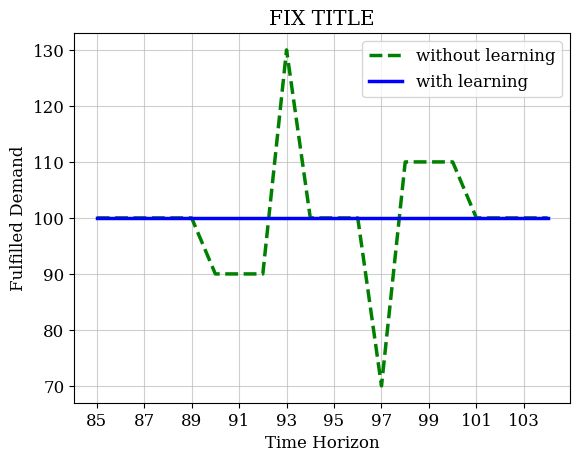

In [50]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=85
end = start+20

ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning', color='green', linestyle='--', linewidth='2.5')

ax.plot(range(start, end), list(value for key, value in cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning', color='blue', linestyle='-', linewidth='2.5')

# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning (ph 30)', color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='green', linestyle='-', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# Show the plot
plt.show()

In [18]:
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
# rc('text', usetex=False)
# fig, ax = plt.subplots()
# 
# # Plot data from the first dataset
# start=88
# end = start+15
# 
# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], color='green', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning', color='green', linestyle='-', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_ncl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], color='blue', linestyle='--', linewidth='2.5')
# 
# ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['Demand_backlog_cost'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='blue', linestyle='-', linewidth='2.5')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# ax.set_title('Amount delivered at customer node')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# # plt.grid(alpha=0.6)
# plt.rcdefaults()
# # plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# # Show the plot
# plt.show()

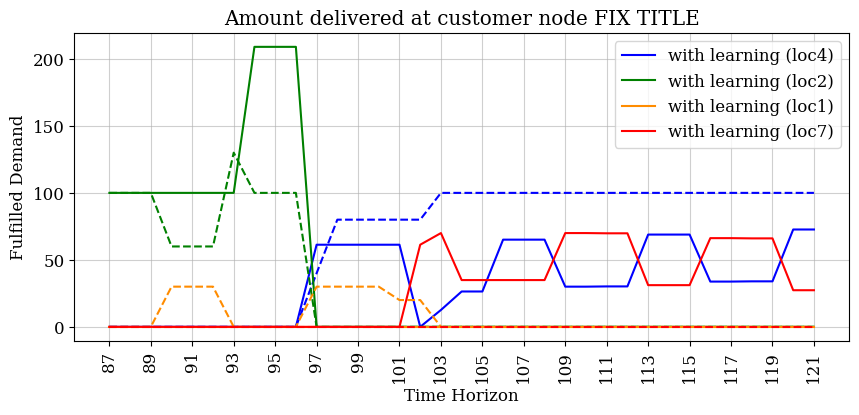

In [49]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=87
end = start+35
focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

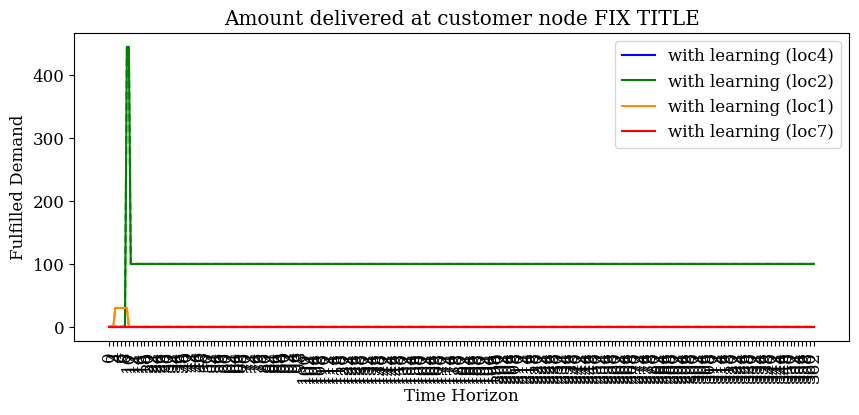

In [29]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=0
end = 363
focal_results_1 = cl_step2_load_results
focal_results_2 = cl_step2_ncl_des_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

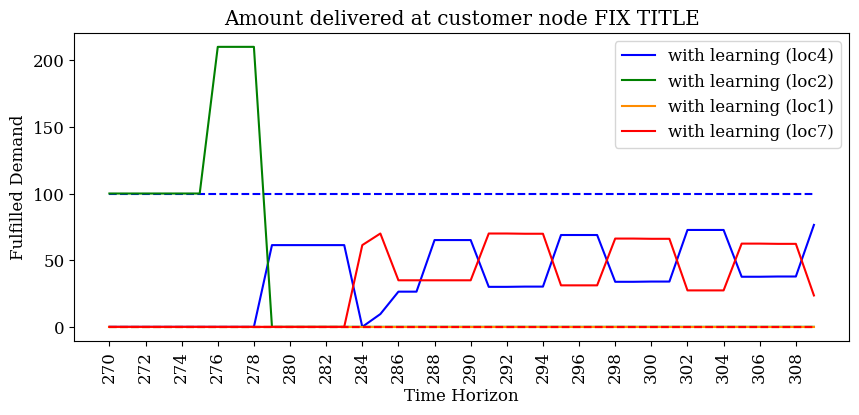

In [46]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=270
end = start + 40
focal_results_1 = cl_step3_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'cl_step2_customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

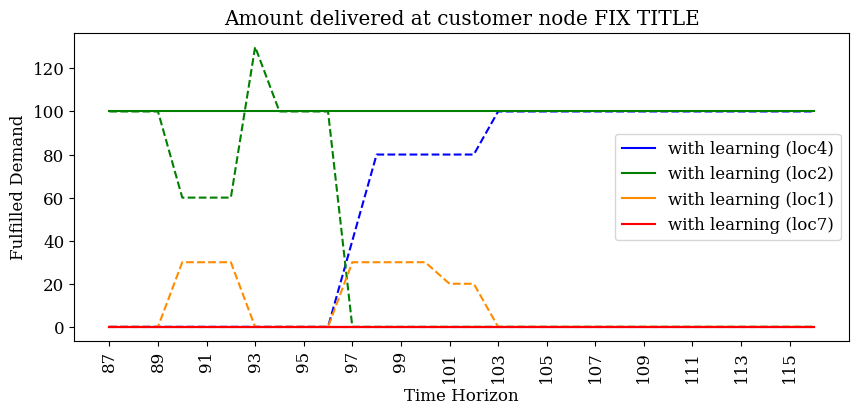

In [21]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=87
end = start+30
focal_results_1 = cl_step2_ncl_des_load_results
focal_results_2 = ncl_load_results

r_cl_loc4 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
r_ncl_loc4 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]

r_cl_loc2 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
r_ncl_loc2 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]

r_cl_loc1 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
r_ncl_loc1 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]

r_cl_loc7 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
r_ncl_loc7 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]

r_cl_dis5 = list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
r_ncl_dis5 = list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]

# r_cl_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_loc1, r_cl_loc7, r_cl_dis5, r_cl_loc4, r_cl_loc2)]

ax.plot(range(start, end), r_cl_loc4, label='with learning (loc4)', color='blue', linestyle='-')
ax.plot(range(start, end), r_ncl_loc4, color='blue', linestyle='--')

ax.plot(range(start, end), r_cl_loc2, label='with learning (loc2)', color='green', linestyle='-')
ax.plot(range(start, end), r_ncl_loc2, color='green', linestyle='--')

ax.plot(range(start, end), r_cl_loc1, label='with learning (loc1)', color='darkorange', linestyle='-')
ax.plot(range(start, end), r_ncl_loc1, color='darkorange', linestyle='--')

ax.plot(range(start, end), r_cl_loc7, label='with learning (loc7)', color='red', linestyle='-')
ax.plot(range(start, end), r_ncl_loc7, color='red', linestyle='--')

# ax.plot(range(start, end), r_cl_dis5, label='with learning (dis5)', color='cyan', linestyle='-')
# ax.plot(range(start, end), r_ncl_dis5, color='cyan', linestyle='--')

# ax.plot(range(start, end), r_cl_tot5, label='with learning (tot5)', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with learning (loc2 process)', color='red', linestyle='-.')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node FIX TITLE')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.xticks(rotation=90)
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# Show the plot
plt.show()

In [22]:
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
# rc('text', usetex=False)
# fig, ax = plt.subplots(figsize=(10,4))
# 
# # Plot data from the first dataset
# start=87
# end = start+30
# 
# r_cl_step2_loc4 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
# r_cl_loc4 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc4')[start:end]
# 
# r_cl_step2_loc2 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
# r_cl_loc2 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc2')[start:end]
# 
# r_cl_step2_loc1 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
# r_cl_loc1 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc1')[start:end]
# 
# r_cl_step2_loc7 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
# r_cl_loc7 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_receive_loc7')[start:end]
# 
# r_cl_step2_dis5 = list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
# r_cl_dis5 = list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end]
# 
# # r_cl_step2_tot5 = [a+b+c+d+e for a,b,c,d,e in zip(r_cl_step2_loc1, r_cl_step2_loc7, r_cl_step2_dis5, r_cl_step2_loc4, r_cl_step2_loc2)]
# 
# ax.plot(range(start, end), r_cl_step2_loc4, label='with step2 learning (loc4)', color='blue', linestyle='-')
# ax.plot(range(start, end), r_cl_loc4, color='blue', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc2, label='with step2 learning (loc2)', color='green', linestyle='-')
# ax.plot(range(start, end), r_cl_loc2, color='green', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc1, label='with step2 learning (loc1)', color='darkorange', linestyle='-')
# ax.plot(range(start, end), r_cl_loc1, color='darkorange', linestyle='--')
# 
# ax.plot(range(start, end), r_cl_step2_loc7, label='with step2 learning (loc7)', color='red', linestyle='-')
# ax.plot(range(start, end), r_cl_loc7, color='red', linestyle='--')
# 
# # ax.plot(range(start, end), r_cl_step2_dis5, label='with step2 learning (dis5)', color='cyan', linestyle='-')
# # ax.plot(range(start, end), r_cl_dis5, color='cyan', linestyle='--')
# 
# # ax.plot(range(start, end), r_cl_step2_tot5, label='with step2 learning (tot5)', color='black', linestyle='-')
# 
# # ax.plot(range(start, end), list(value for key, value in cl_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='without learning (loc2 process)', color='blue', linestyle='-.')
# # ax.plot(range(start, end), list(value for key, value in cl_step2_load_results.output['P'].items() if key[0]=='loc2' and key[1]=='com1_process')[start:end], label='with step2 learning (loc2 process)', color='red', linestyle='-.')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# ax.set_title('Amount delivered at customer node FIX TITLE')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# plt.xticks(rotation=90)
# # plt.grid(alpha=0.6)
# plt.rcdefaults()
# plt.savefig(fname = 'customer_node_delivery_compare', dpi = 300)
# # Show the plot
# plt.show()

In [19]:
# x = list(range(len(list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
# y = list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# # y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# # Plotting
# plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# # plt.plot(x, y2, marker='x', label='approx_obj')
# plt.title('Delivery under demand variability')
# plt.xlabel('Time Horizon')
# plt.ylabel('Delivery Level')
# plt.grid(True)
# plt.legend()
# plt.savefig(fname = 'MPC_demand', dpi = 300)
# plt.show()

In [20]:
# x = list(range(len(list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
# y = list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# # y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# # Plotting
# plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# # plt.plot(x, y2, marker='x', label='approx_obj')
# plt.title('Unmet demand under demand variability')
# plt.xlabel('Time Horizon')
# plt.ylabel('Unmet Demand Level')
# plt.grid(True)
# plt.legend()
# plt.savefig(fname = 'MPC_demand_penalty', dpi = 300)
# plt.show()

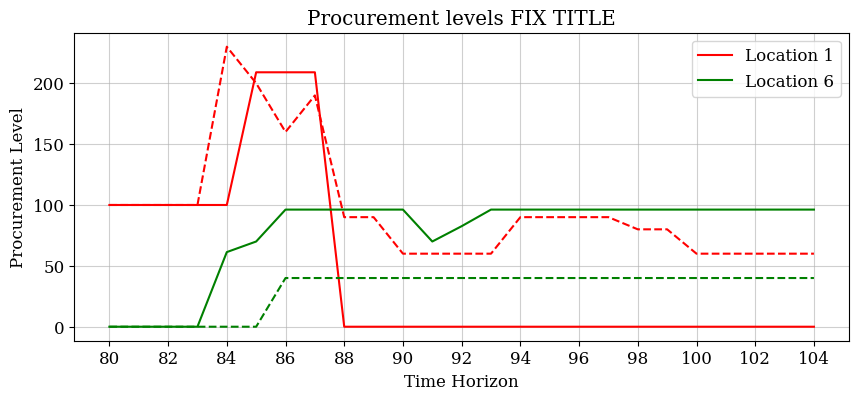

In [47]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = cl_load_results
focal_results_2 = ncl_load_results

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], label='Location 1', color='red', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], color='red', linestyle='--')

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], label='Location 6', color='green', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], color='green', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels FIX TITLE')
ax.set_xticks(range(start, end, 2))
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_procurement_compare', dpi = 300)
# Show the plot
plt.show()

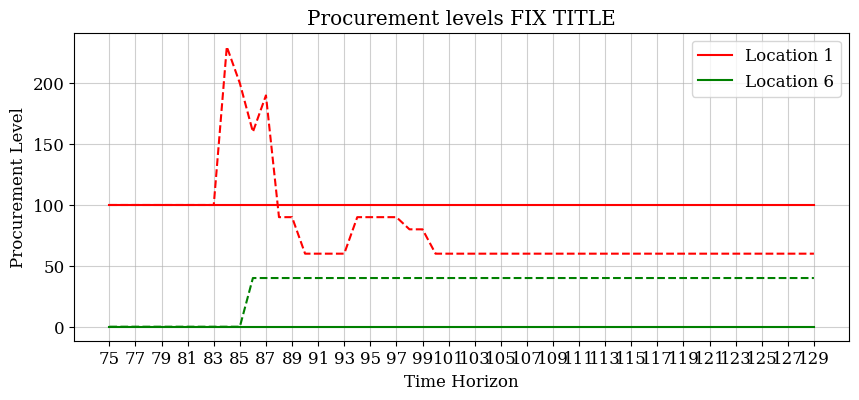

In [40]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=75
end = 130

focal_results_1 = cl_step3_load_results
focal_results_2 = ncl_load_results

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], label='Location 1', color='red', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')[start:end], color='red', linestyle='--')

ax.plot(range(start, end), list(value for key, value in focal_results_1.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], label='Location 6', color='green', linestyle='-')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')[start:end], color='green', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels FIX TITLE')
ax.set_xticks(range(start, end, 2))
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_procurement_compare', dpi = 300)
# Show the plot
plt.show()

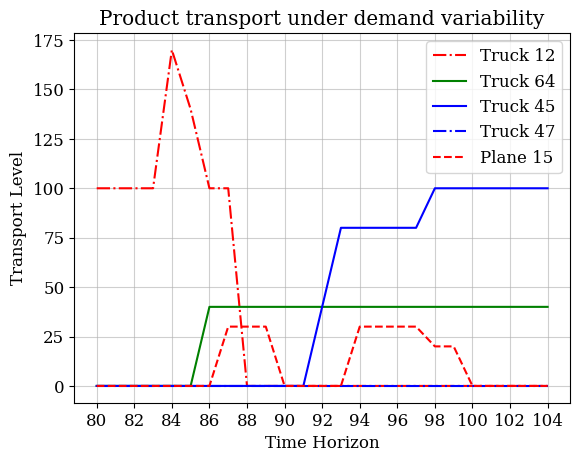

In [24]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results

a=1
b=2
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-.')

a=6
b=4
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-.')

a=1
b=5
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='--')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

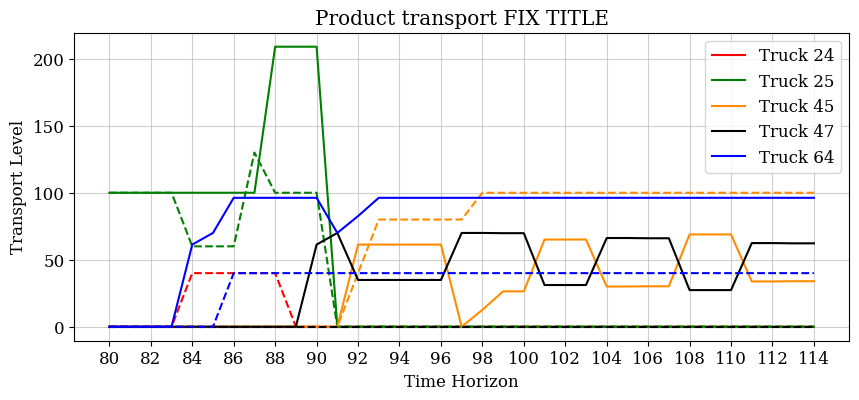

In [37]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(10,4))

# Plot data from the first dataset
start=80
end = start+35

focal_results_1 = ncl_load_results
focal_results_2 = cl_load_results

a=2
b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='-')

a=2
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='darkorange', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='darkorange', linestyle='-')

a=4
b=7
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='-')

a=6
b=4
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='blue', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='blue', linestyle='-')

# a=3
# b=4
# # ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='brown', linestyle='--')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='brown', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport FIX TITLE')
ax.legend(loc='upper right')
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_logistics_compare', dpi = 300)
# Show the plot
plt.show()

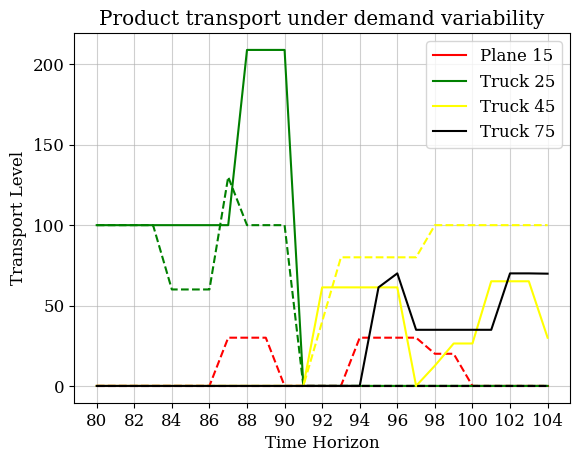

In [51]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=80
end = start+25

focal_results_1 = ncl_load_results
focal_results_2 = cl_load_results

a=1
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='red', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Plane {a}{b}', color='red', linestyle='-')

a=2
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='green', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='yellow', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='yellow', linestyle='-')

a=7
b=5
# ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_1.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], color='black', linestyle='--')
ax.plot(range(start, end), list(value for key, value in focal_results_2.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out')[start:end], label=f'Truck {a}{b}', color='black', linestyle='-')

# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_store_discharge')[start:end], label='Loc 5 discharge', color='cyan', linestyle='-')
# ax.plot(range(start, end), list(value for key, value in focal_results_2.output['P'].items() if key[0]=='loc5' and key[1]=='com1_process')[start:end], label='Loc 5 process', color='cyan', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
plt.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

In [56]:
ncl_load_results.output.keys()

dict_keys(['termination', 'LB', 'UB', 'n_cons', 'n_vars', 'n_binvars', 'n_intvars', 'n_convars', 'n_nonzero', 'P', 'B', 'C', 'S', 'R', 'Inv', 'P_m', 'P_material_m', 'Cap_P', 'Cap_S', 'P_location', 'P_location_material_m', 'S_location', 'R_location', 'C_location', 'B_location', 'P_network', 'S_network', 'R_network', 'C_network', 'B_network', 'Trans_cost_network', 'Fopex_process', 'Vopex_process', 'Capex_process', 'Incidental_process', 'Capex_storage', 'Fopex_location', 'Vopex_location', 'Capex_location', 'Incidental_location', 'Fopex_network', 'Vopex_network', 'Capex_network', 'Incidental_network', 'Inv_network', 'Cost', 'Inv_cost', 'Inv_cost_location', 'Inv_cost_network', 'X_F', 'Cap_F', 'Exp_R', 'Exp_F', 'Exp_F_network', 'Exp', 'Capex_transport', 'Vopex_transport', 'Fopex_transport', 'Capex_transport_network', 'Vopex_transport_network', 'Fopex_transport_network', 'X_P', 'X_S', 'Demand_penalty', 'Demand_penalty_location', 'Demand_penalty_network', 'Demand_penalty_cost', 'Demand_penalty

In [28]:
ncl_load_results.output['objective']

835327.3999999999

In [52]:
cl_load_results.output['objective']

856371.6058953165

In [54]:
cl_step2_ncl_des_load_results.output['objective']

546195.6

In [55]:
cl_step2_load_results.output['objective']

612270.0921349862

In [60]:
cl_step2_load_results.output['Demand_penalty_network'][('com1_sold', 0)]  + cl_step2_load_results.output['Demand_backlog_cost_network'][('com1_sold', 0)]

175470.0

In [59]:
cl_step2_ncl_des_load_results.output['Demand_penalty_network'][('com1_sold', 0)]  + cl_step2_ncl_des_load_results.output['Demand_backlog_cost_network'][('com1_sold', 0)]

175470.0

In [63]:
# # --- Input Data -------------------------------------------------------------
# categories = ["Bin CAPEX", "Transport CAPEX", "OPEX", "Transport OPEX", "Backlog Penalty"]
# 
# # Replace these with your actual values
# scenario1 = [10, 20, 35, 15, 5]    # e.g., without learning
# scenario2 = [8, 18, 30, 20, 3]     # e.g., with learning
# 
# # Labels for scenarios
# scenario_labels = ["Without Learning", "With Learning"]
# 
# # --- Plotting ---------------------------------------------------------------
# x = np.arange(len(categories))       # positions of categories
# width = 0.35                         # width of each bar
# 
# fig, ax = plt.subplots(figsize=(10, 5))
# 
# # Bars
# bars1 = ax.bar(x - width/2, scenario1, width, label=scenario_labels[0], color='darkblue')
# bars2 = ax.bar(x + width/2, scenario2, width, label=scenario_labels[1], color='darkred')
# 
# # --- Labels & Styling -------------------------------------------------------
# ax.set_ylabel("Cost")
# ax.set_title("Cost Breakdown Comparison Across Scenarios")
# ax.set_xticks(x)
# ax.set_xticklabels(categories, rotation=30, ha='right')
# ax.legend(loc='upper left')
# 
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# 
# plt.show()


In [68]:
ncl_load_results.output.keys()

dict_keys(['termination', 'LB', 'UB', 'n_cons', 'n_vars', 'n_binvars', 'n_intvars', 'n_convars', 'n_nonzero', 'P', 'B', 'C', 'S', 'R', 'Inv', 'P_m', 'P_material_m', 'Cap_P', 'Cap_S', 'P_location', 'P_location_material_m', 'S_location', 'R_location', 'C_location', 'B_location', 'P_network', 'S_network', 'R_network', 'C_network', 'B_network', 'Trans_cost_network', 'Fopex_process', 'Vopex_process', 'Capex_process', 'Incidental_process', 'Capex_storage', 'Fopex_location', 'Vopex_location', 'Capex_location', 'Incidental_location', 'Fopex_network', 'Vopex_network', 'Capex_network', 'Incidental_network', 'Inv_network', 'Cost', 'Inv_cost', 'Inv_cost_location', 'Inv_cost_network', 'X_F', 'Cap_F', 'Exp_R', 'Exp_F', 'Exp_F_network', 'Exp', 'Capex_transport', 'Vopex_transport', 'Fopex_transport', 'Capex_transport_network', 'Vopex_transport_network', 'Fopex_transport_network', 'X_P', 'X_S', 'Demand_penalty', 'Demand_penalty_location', 'Demand_penalty_network', 'Demand_penalty_cost', 'Demand_penalty

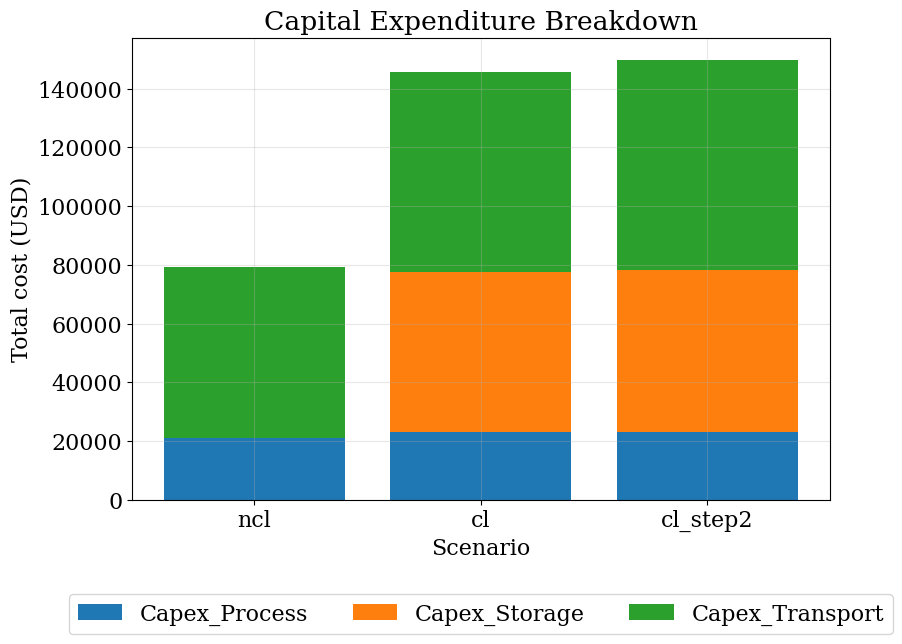

In [97]:
# Your data
ncl_capex_storage = sum(v for k,v in ncl_load_results.output['Capex_storage'].items())
cl_capex_storage = sum(v for k,v in cl_load_results.output['Capex_storage'].items())
cl_step2_capex_storage = sum(v for k,v in cl_step2_load_results.output['Capex_storage'].items())
cl_step3_capex_storage = sum(v for k,v in cl_step3_load_results.output['Capex_storage'].items())

ncl_capex_process = sum(v for k,v in ncl_load_results.output['Capex_network'].items()) - ncl_capex_storage
cl_capex_process = sum(v for k,v in cl_load_results.output['Capex_network'].items()) - cl_capex_storage
cl_step2_capex_process = sum(v for k,v in cl_step2_load_results.output['Capex_network'].items()) - cl_step2_capex_storage
cl_step3_capex_process = sum(v for k,v in cl_step3_load_results.output['Capex_network'].items()) - cl_step3_capex_storage

ncl_capex_transport = sum(v for k,v in ncl_load_results.output['Capex_transport_network'].items())
cl_capex_transport = sum(v for k,v in cl_load_results.output['Capex_transport_network'].items())
cl_step2_capex_transport = sum(v for k,v in cl_step2_load_results.output['Capex_transport_network'].items())
cl_step3_capex_transport = sum(v for k,v in cl_step3_load_results.output['Capex_transport_network'].items())

data = [
    [ncl_capex_process, cl_step2_capex_process, cl_step3_capex_process], # Process Capex
    [ncl_capex_storage, cl_step2_capex_storage, cl_step3_capex_storage], # Storage Capex
    [ncl_capex_transport, cl_step2_capex_transport, cl_step3_capex_transport]  # Transport Capex
]

# Transpose the data for plotting
data_transposed = np.array(data)

# Create stacked bar plot
rc('font', **{'family': 'serif',
           'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize = (9,6))
labels = ['Capex_Process', 'Capex_Storage', 'Capex_Transport']
for i in range(len(data)):
    bar = ax.bar(np.arange(len(data[i])), data_transposed[i], bottom = np.sum(data_transposed[:i], axis=0), label = labels[i])

# Add labels, title, and legend
ax.set_xlabel('Scenario')
ax.set_ylabel('Total cost (USD)')
ax.set_title('Capital Expenditure Breakdown')

xtick_positions = np.arange(len(data[0]))
xtick_labels = ['ncl', 'cl', 'cl_step2']
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.grid(zorder=0, alpha = 0.3)
plt.rcdefaults()

plt.savefig(fname = 'Capex Cost Breakdown', dpi = 300)
# Show the plot
plt.show()

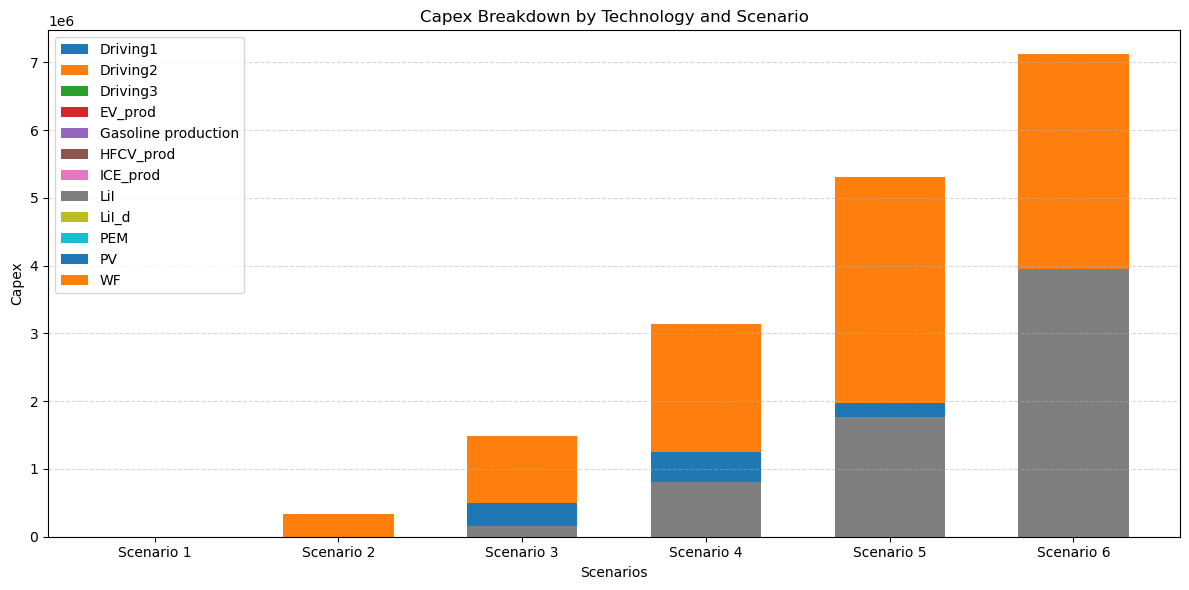

In [62]:
# Initialize technologies and capex data
technologies = [('HO', 'Driving1', 0), ('HO', 'Driving2', 0), ('HO', 'Driving3', 0),
                ('HO', 'EV_prod', 0), ('HO', 'Gasoline production', 0),
                ('HO', 'HFCV_prod', 0), ('HO', 'ICE_prod', 0), ('HO', 'LiI', 0),
                ('HO', 'LiI_d', 0), ('HO', 'PEM', 0), ('HO', 'PV', 0),
                ('HO', 'WF', 0)]

# Capex data (example, replace this with your actual data)
capex_data = [
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 0.0,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 0.0},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 0.0,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 335842.5566191988},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 162203.35236218787,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 341488.63966309716,
     ('HO', 'WF'): 977833.8151999465},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 814381.8026258291,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 439470.26834187517,
     ('HO', 'WF'): 1882113.1042218911},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 1770789.0394942726,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 207876.77348638972,
     ('HO', 'WF'): 3333712.8110114653},
    {('HO', 'Driving1'): 0.0, ('HO', 'Driving2'): 0.0, ('HO', 'Driving3'): 0.0,
     ('HO', 'EV_prod'): 0.0, ('HO', 'Gasoline production'): 0.0,
     ('HO', 'HFCV_prod'): 0.0, ('HO', 'ICE_prod'): 0.0, ('HO', 'LiI'): 3951409.887033983,
     ('HO', 'LiI_d'): 0.0, ('HO', 'PEM'): 0.0, ('HO', 'PV'): 0.0,
     ('HO', 'WF'): 3166282.786141873}
]

# Initialize a dictionary to store Capex values for each technology per scenario
capex_by_tech = {tech[1]: [0] * 6 for tech in technologies}  # tech[1] is the technology name (e.g., 'Driving1')

# Extract Capex values for each technology per scenario
for i in range(6):  # Loop over each scenario
    for tech in technologies:
        tech_name = tech[1]  # Extract technology name (e.g., 'EV_prod')
        
        # Check if tech_name exists in the current scenario's Capex data
        tech_key = ('HO', tech_name)  # Create the key to search in capex_data
        if tech_key in capex_data[i]:
            capex_value = capex_data[i][tech_key]
        else:
            capex_value = 0  # If the technology doesn't have a Capex value in this scenario
        
        capex_by_tech[tech_name][i] = capex_value  # Store Capex value for the technology in the respective scenario

# === Prepare data for plotting ===
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.6
x = range(6)

# Create a stacked bar plot with all technologies, including those with zero values
bottoms = [0] * 6  # Start with all bottoms at zero for stacking
for tech, capex_values in capex_by_tech.items():
    # Only plot technologies with non-zero values
    ax.bar(x, capex_values, label=tech, width=bar_width, bottom=bottoms)
    bottoms = [bottoms[i] + capex_values[i] for i in x]  # Update bottoms for stacking

ax.set_xlabel("Scenarios")
ax.set_ylabel("Capex")
ax.set_title("Capex Breakdown by Technology and Scenario")
ax.set_xticks(x)
ax.set_xticklabels([f"Scenario {i+1}" for i in x])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()